In [5]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd 
import kit as erk 

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# GMB Interactive Plots

<Axes: >

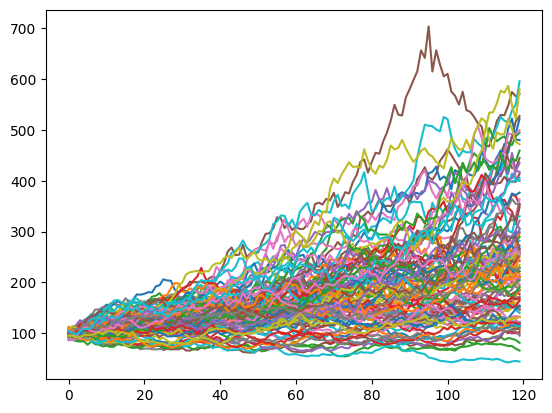

In [10]:
erk.gbm(10, 100, mu=0.1).plot(legend=False)

In [21]:
def show_gbm(n_scenarios, mu, sigma):
    """
    Draw the results of stock price evolution under a Geometric Brownian Motion model
    """
    s_0 = 100
    prices = erk.gbm(n_scenarios=n_scenarios, mu=mu, sigma=sigma, s_0=s_0)
    ax = prices.plot(legend=False, color="Indianred", alpha=0.5, linewidth =2, figsize=(12,5))
    ax.axhline(y=s_0, ls=":", color="black")
    ax.set_ylim(top=400)
    # draw the dot at the origin
    ax.plot(0, s_0, marker='o', color='darkred', alpha=0.2)

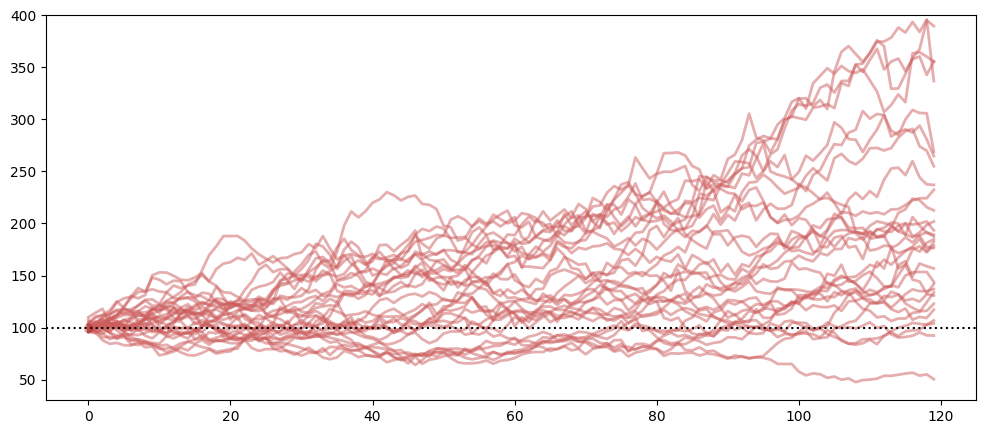

In [22]:
show_gbm(30, 0.07, 0.15)

In [19]:
gbm_controls = widgets.interactive(show_gbm, 
                                   n_scenarios= (1, 100, 1),
                                   mu=(-0.2, 0.2, 0.01),
                                   sigma=(0, 0.3, 0.01))

In [20]:
display(gbm_controls)

interactive(children=(IntSlider(value=50, description='n_scenarios', min=1), FloatSlider(value=0.0, descriptio…

## Interative CPPI Simulation - Monte Carlo

In [61]:
import matplotlib.pyplot as plt

In [ ]:
from pygments.util import terminal_encoding
def show_cppi(n_scenarios=50, mu=0.07, sigma=0.15, m=3, floor=0.8,riskfree_rate=0.03, y_max=100):
    """
    Plot the results of Monte Carlo Simulation of CPPI
    """

    start = 100
    sim_rets = erk.gbm(n_scenarios=n_scenarios, mu=mu, sigma=sigma, prices=False, steps_per_year=12)
    risky_r = pd.DataFrame(sim_rets)

    # Run the back test
    btr = erk.run_cppi(risky_r = pd.DataFrame(risky_r), riskfree_rate=riskfree_rate, m=m, start=start, floor=floor)
    wealth= btr["Wealth"]
    terminal_wealth = wealth.iloc[-1]


    # Calculate the terminal wealth stats
    y_max = wealth.values.max()*y_max/100
    terminal_wealth = wealth.iloc[-1]
    
    tw_mean = terminal_wealth.mean()
    tw_median = terminal_wealth.median()
    failure_mask = np.less(terminal_wealth, start*floor)
    n_failures = failure_mask.sum()
    p_fail = n_failures/n_scenarios


    #Plot
    fig, (wealth_ax, hist_ax) = plt.subplots(nrows=1, ncols=2, sharey=True, gridspec_kw={'width_ratios':[3,2]}, figsize=(24,9))
    plt.subplots_adjust(wspace=0.0)

    wealth.plot(ax=wealth_ax, legend=False, alpha=0.3, color="indianred")
    wealth_ax.axhline(y=start, ls=":", color="black")
    wealth_ax.axhline(y=start*floor, ls="--", color="red")

    terminal_wealth.plot.hist(ax=hist_ax, bins=50, ec='w', fc='indianred', orientation='horizontal')
    hist_ax.axhline(y=start, ls=':', color='black')

    


In [ ]:
cppi_controls = widgets.interactive(show_cppi, 
                                    n_scenarios=widgets.IntSlider(min=1, max=1000, step=5, value=50),
                                    mu=(0.,+.2,.01),
                                    sigma=(0, .30,.05),
                                    floor=(0, 2, .1),
                                    m=(1, 5, .5),
                                    riskfree_rate=(0, .05, .01),
                                    y_max=widgets.IntSlider(min=0, max=100, step=1, value=100,
                                                            description='Zoom Y axis'))

In [67]:
display(cppi_controls)

interactive(children=(IntSlider(value=50, description='n_scenarios', max=1000, min=1, step=5), FloatSlider(val…

In [ ]:
t